# Introduction: The Extended Church-Turing Thesis and the Quantum Trilemma

Before exploring the specific experimental setup and calculations detailed in the paper, it is essential to understand the theoretical foundation that motivates this work. The paper addresses one of the most profound open questions at the intersection of physics, mathematics, and computer science: the validity of the Extended Church-Turing thesis.

### The Extended Church-Turing Thesis
The Extended Church-Turing thesis is a foundational tenet of computer science. It asserts that any computational function on a realistic physical device can be efficiently computed on a probabilistic Turing Machine. In simpler terms, it assumes that classical computers can efficiently simulate any physical process in the universe. 

### The Fundamental Trilemma
The very existence of Shor's factoring algorithm poses a fundamental trilemma, suggesting that at least one foundational tenet of physics, mathematics, or computer science must be untrue. Shor's algorithm states that efficient factoring of large composite numbers can be performed on a quantum computer, which is theoretically thought to be a realistic physical device. 

Because factoring is presumed to be computationally intractable for classical systems, we are left with three distinct possibilities:
1. **Physics breaks down:** A scalable quantum computer is not actually a realistic physical device, perhaps because quantum mechanics fails to hold for a large number of qubits.
2. **Mathematics/Complexity Theory is incomplete:** If scalable quantum computers are realistic, and the Extended Church-Turing thesis is correct, then a classical, efficient factoring algorithm must exist (which would break modern public-key cryptography like RSA).
3. **Computer Science must be revised:** The Extended Church-Turing thesis itself is fundamentally wrong.

Currently, there is no physical evidence that quantum mechanics breaks down at scale, nor is there any mathematical proof of an efficient classical factoring algorithm. This leaves the scientific community to critically examine the validity of the Extended Church-Turing thesis.

### Resolving the Trilemma 
To directly contradict the Extended Church-Turing thesis, one would need to build a physical device capable of efficiently performing a task that is strongly believed to be intractable for classical computers. 

While building a universal quantum computer capable of running Shor's algorithm at scale is technologically out of reach right now, this paper provides an alternative route. Rather than engineering a universal quantum machine, the authors experimentally perform a specific, highly non-classical scattering task. Scaling this particular task to large numbers of photons is a much simpler engineering challenge than building a universal quantum computer. If this specific task can be scaled up to a regime where classical verification is no longer possible, it will provide strong evidence against the Extended Church-Turing thesis, effectively resolving the trilemma.

## The Mathematical Core: Determinants vs. Permanents

To understand the specific task that challenges the Extended Church-Turing thesis, we first need to look at two closely related mathematical concepts: the determinant and the permanent of a matrix. 

### The Formulaic Similarity
For an $n \times n$ matrix $A$, the determinant is defined using the Leibniz formula, which sums over all possible permutations $\sigma$ of the symmetric group $S_n$:

$$Det(A) = \sum_{\sigma \in S_n} \text{sgn}(\sigma) \prod_{i=1}^n A_{i,\sigma(i)}$$

Here, $\text{sgn}(\sigma)$ is the sign of the permutation ($+1$ for even permutations, $-1$ for odd permutations). 

The **permanent** of a matrix has an almost identical definition, but it simply drops the alternating sign term:

$$Per(A) = \sum_{\sigma \in S_n} \prod_{i=1}^n A_{i,\sigma(i)}$$

Despite their striking visual similarity, this single change—dropping the permutation sign—results in a monumental shift in computational difficulty.

### The Complexity Chasm: Polynomial vs. Exponential
Because of the alternating sign, the determinant possesses geometric properties (like representing the signed volume of a parallelepiped) and algebraic symmetries. These properties allow us to use row operations (Gaussian elimination or LU decomposition) to calculate the determinant in **$O(n^3)$** time. It is a highly efficient, polynomial-time operation on classical computers.

The permanent, however, lacks these symmetries. You cannot use Gaussian elimination to find a permanent because adding a multiple of one row to another fundamentally changes the permanent's value. 
* A naive calculation using the definition requires summing over $n!$ permutations, which is $O(n!)$.
* Even the most efficient known exact algorithm (Ryser's algorithm) takes **$O(n 2^n)$** time. 

For large matrices, calculating the permanent scales exponentially, rapidly becoming intractable for classical computers. 

### Understanding the Intractability: NP vs. #P
To contextualize just how difficult calculating the permanent is, we can look at classical complexity classes:

* **NP (Nondeterministic Polynomial time):** This class contains decision problems (questions with a "yes" or "no" answer) where, if the answer is "yes", a proposed solution can be *verified* quickly (in polynomial time). For example, the Traveling Salesman Problem asks: *"Is there a route shorter than distance $X$?"* These are generally believed to be classically intractable to solve efficiently.
* **#P (Sharp-P):** This is the "counting" equivalent of NP. Instead of asking if a solution exists, it asks *how many* solutions exist. For example: *"How many valid Traveling Salesman routes are shorter than distance $X$?"*

Problems in #P are inherently harder than those in NP because you must count every valid state rather than just finding one. Calculating the permanent of a matrix is a **#P-complete** problem, meaning it is among the hardest problems in the #P class. If you could efficiently calculate the permanent, you could efficiently solve all NP problems and collapse the polynomial hierarchy.

Running complexity benchmarks...
Size  2x2  | Det Time: 0.000053s | Perm Time: 0.000014s
Size  4x4  | Det Time: 0.000014s | Perm Time: 0.000045s
Size  5x5  | Det Time: 0.000012s | Perm Time: 0.000232s
Size  6x6  | Det Time: 0.000011s | Perm Time: 0.001129s
Size  8x8  | Det Time: 0.000010s | Perm Time: 0.049335s
Size 10x10 | Det Time: 0.000047s | Perm Time: 5.020353s


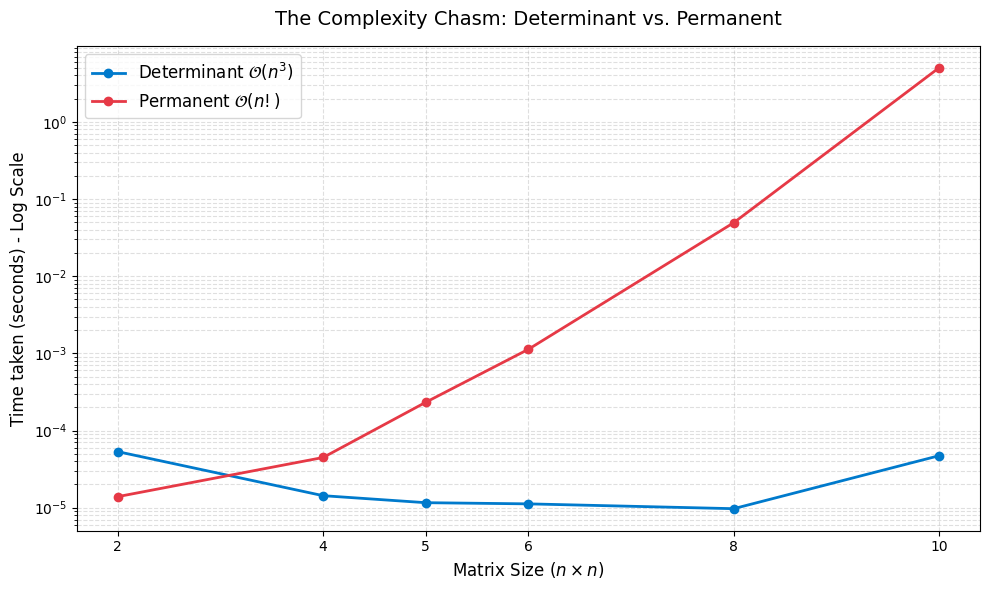

In [2]:
import numpy as np
import itertools
import time
import matplotlib.pyplot as plt

def calculate_permanent_naive(A):
    """
    Calculates the permanent of a matrix using the naive O(n!) definition.
    This directly mirrors the mathematical formula (summing over all permutations)
    without the alternating sign term used in determinants.
    """
    n = A.shape[0]
    perm = 0
    
    # Iterate over all possible permutations of the columns
    for p in itertools.permutations(range(n)):
        # Calculate the product of the elements for this specific permutation
        prod = 1
        for i in range(n):
            prod *= A[i, p[i]]
        perm += prod
        
    return perm

# Matrix sizes to benchmark
# Warning: Do not push this much past 10! 
# 10! = 3,628,800 permutations. 11! = 39,916,800 (will take a minute or two).
sizes = [2, 4, 5, 6, 8, 10]

det_times = []
perm_times = []

print("Running complexity benchmarks...")

for n in sizes:
    # Generate a random n x n matrix
    A = np.random.rand(n, n)
    
    # --- Benchmark Determinant ---
    start_det = time.perf_counter()
    np.linalg.det(A) # NumPy uses highly optimized O(n^3) algorithms
    end_det = time.perf_counter()
    det_times.append(end_det - start_det)
    
    # --- Benchmark Permanent ---
    start_perm = time.perf_counter()
    calculate_permanent_naive(A) # Our naive O(n!) implementation
    end_perm = time.perf_counter()
    perm_times.append(end_perm - start_perm)
    
    print(f"Size {n:>2}x{n:<2} | Det Time: {det_times[-1]:.6f}s | Perm Time: {perm_times[-1]:.6f}s")

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))

# We use a logarithmic scale for the y-axis because the difference in time
# becomes so massive that a linear scale would squish the determinant line flat.
plt.plot(sizes, det_times, marker='o', label='Determinant $\\mathcal{O}(n^3)$', color='#007acc', linewidth=2)
plt.plot(sizes, perm_times, marker='o', label='Permanent $\\mathcal{O}(n!)$', color='#e63946', linewidth=2)

plt.yscale('log')
plt.xlabel('Matrix Size ($n \\times n$)', fontsize=12)
plt.ylabel('Time taken (seconds) - Log Scale', fontsize=12)
plt.title('The Complexity Chasm: Determinant vs. Permanent', fontsize=14, pad=15)
plt.xticks(sizes)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()

plt.show()

### The True Goal of the Experiment
It is important to clarify a crucial nuance: the goal of the experiment detailed in this paper is **not** to build a quantum machine that explicitly calculates and outputs the permanent of an arbitrary user-provided matrix. 

Instead, the paper focuses on simulating a specific physical process—the scattering of identical particles through a linear optical network. Quantum mechanics dictates that the probability amplitudes of these multi-particle scattering events are directly proportional to the permanents of various $n \times n$ sub-matrices. 

By physically running this experiment, the device naturally *samples* from this highly complex probability distribution. To simulate this exact same sampling process on a classical computer, one would have to calculate these #P-complete permanents over and over again. As the number of particles ($n$) grows, the classical simulation is choked by the exponential math, while the physical device generates the sample simply by letting the natural physics play out.

## The Physics of Boson Sampling: Where the Permanent Arises

To understand why calculating the permanent is physically necessary, we must model our linear optical network using the framework of quantum mechanics. Specifically, we will look at how the physical properties of bosons dictate the underlying mathematics.

### 1. Defining the Input State
In quantum optics, we create a photon in a specific spatial mode $i$ by applying a creation operator $a_i^\dagger$ to the vacuum state $|0\rangle$. 

For simplicity, let's assume we inject exactly $n$ single photons into the first $n$ input ports of our $m$-mode linear optical network (where $n \le m$). The input Fock state $|S\rangle$ is mathematically written as the product of $n$ creation operators acting on the vacuum:

$$|S\rangle = a_1^\dagger a_2^\dagger \dots a_n^\dagger |0\rangle$$

### 2. The Unitary Evolution of the Network
When the photons pass through the linear optical circuit (which is made of beam splitters and phase shifters), the spatial modes are mixed. A photon entering mode $i$ has a probability amplitude $U_{i,j}$ of exiting at mode $j$.

Mathematically, the circuit applies a unitary transformation $U$ that evolves each input creation operator into a linear combination of output creation operators:

$$a_i^\dagger \rightarrow \sum_{j=1}^m U_{i,j} a_j^\dagger$$

### 3. The Output State
To find the state of the system after the photons have traversed the network, we substitute the unitary transformation into our initial state equation. The output state $|\psi_{\text{out}}\rangle$ becomes a massive product of sums:

$$|\psi_{\text{out}}\rangle = \left( \sum_{j_1=1}^m U_{1,j_1} a_{j_1}^\dagger \right) \left( \sum_{j_2=1}^m U_{2,j_2} a_{j_2}^\dagger \right) \dots \left( \sum_{j_n=1}^m U_{n,j_n} a_{j_n}^\dagger \right) |0\rangle$$

If you were to expand this product out completely, you would get $m^n$ terms, representing every conceivable way the $n$ photons could distribute themselves across the $m$ output modes.

### 4. Calculating the Probability Amplitude (The Permanent)
Now, suppose we place detectors at specific output modes and want to find the probability amplitude of detecting exactly one photon in specific target modes, say $k_1, k_2, \dots, k_n$. This specific target configuration is our output state $|T\rangle$:

$$|T\rangle = a_{k_1}^\dagger a_{k_2}^\dagger \dots a_{k_n}^\dagger |0\rangle$$

To find the probability amplitude for this specific scattering event, we need to calculate the inner product $\langle T | \psi_{\text{out}} \rangle$. In algebraic terms, we need to extract the coefficient in front of the specific term $a_{k_1}^\dagger a_{k_2}^\dagger \dots a_{k_n}^\dagger |0\rangle$ from the massive expanded polynomial in Step 3.

Here is where the physics of bosons dictates the math. **Because photons are bosons, their creation operators commute:**

$$[a_x^\dagger, a_y^\dagger] = a_x^\dagger a_y^\dagger - a_y^\dagger a_x^\dagger = 0$$

This means $a_x^\dagger a_y^\dagger = a_y^\dagger a_x^\dagger$. The order in which the photons are created at the detectors does not matter. 

Because the order doesn't matter, there are multiple ways to form the exact same target state $a_{k_1}^\dagger \dots a_{k_n}^\dagger$ when multiplying out the brackets. Specifically, a valid term is formed by picking one target mode from the first bracket, a different target mode from the second bracket, and so on. 

This means we must sum over every possible permutation $\sigma$ that maps the $n$ input photons to the $n$ target output modes. The coefficient we extract is the sum of the products of the transition amplitudes for every permutation:

$$\langle T | \psi_{\text{out}} \rangle = \sum_{\sigma \in S_n} U_{1, k_{\sigma(1)}} U_{2, k_{\sigma(2)}} \dots U_{n, k_{\sigma(n)}}$$

**This equation is the exact, formal definition of the permanent.** Specifically, it is the permanent of the $n \times n$ submatrix of $U$ formed by the $n$ input rows and the $n$ output columns. 

**The Conclusion:**
Because photons are indistinguishable bosons, quantum mechanics requires us to add the amplitudes of all possible paths they could take to reach the detectors. This summation perfectly mirrors the #P-complete calculation of the permanent. A classical computer chokes on this exponential sum, but the optical network computes it naturally through physical interference.

## The Fermionic Contrast: Anti-Commutation and the Determinant

A natural question arises: what if we performed this exact same experiment using identical fermions (like electrons) instead of identical bosons (photons)? 

If we swap the particle type, the underlying quantum physics fundamentally changes, and so does the computational complexity. 

### The Physics: Pauli Exclusion and Anti-Commutation
Fermions obey the Pauli Exclusion Principle, which dictates that no two identical fermions can occupy the exact same quantum state. Mathematically, this is expressed by the fact that fermionic creation operators **anti-commute**:

$$\{a_x^\dagger, a_y^\dagger\} = a_x^\dagger a_y^\dagger + a_y^\dagger a_x^\dagger = 0$$

This implies a crucial sign flip whenever we swap the order of two operators:

$$a_x^\dagger a_y^\dagger = -a_y^\dagger a_x^\dagger$$

### The Math: Alternating Signs and the Determinant
If we were to repeat the rigorous mathematical derivation from the previous section using fermions, we would still expand the massive polynomial of output states, and we would still sum over all permutations $\sigma$ of the particles routing to the target modes. 

However, because every pairwise swap of fermionic operators introduces a minus sign, the overall sign of any given term in our sum depends entirely on whether it takes an even or odd number of swaps to reach that permutation. We denote this parity as the sign of the permutation, $\text{sgn}(\sigma)$.

The resulting transition amplitude equation becomes:

$$\langle T | \psi_{\text{out}} \rangle = \sum_{\sigma \in S_n} \text{sgn}(\sigma) U_{1, k_{\sigma(1)}} U_{2, k_{\sigma(2)}} \dots U_{n, k_{\sigma(n)}}$$

**This equation is the exact, formal definition of the determinant.** Specifically, it is the determinant of the $n \times n$ submatrix of $U$.

### The Computational Conclusion: Fermions are "Easy"
As we demonstrated earlier in our Python benchmark, calculating the determinant is a highly efficient $O(n^3)$ process on a classical computer. 

Because the probability amplitudes for non-interacting fermions reduce to determinants, **"Fermion Sampling" can be efficiently simulated on a classical computer.** It does not challenge the Extended Church-Turing thesis. It is the unique, sign-free commutativity of bosons that forces the #P-complete permanent into existence, making Boson Sampling classically intractable and quantumly advantageous.

## The Computational Race: Alice vs. Bob

To clearly illustrate the practical implications of Boson Sampling and the collapse of classical simulation, the authors of the paper frame the experiment as a race between two participants: Alice and Bob. 

They are both given the exact same task: given a specific unitary matrix $U$ (representing the linear optical circuit) and a specific input configuration of $n$ photons, they must generate a representative sample from the resulting probability distribution. The winner is whoever returns an accurate sample first.

### Alice: The Classical Contender
Alice represents the classical regime and the Extended Church-Turing thesis. She possesses only classical computing resources. 

To complete the task, Alice is given the mathematical description of the $m \times m$ unitary matrix $U$. She must use her classical computer to crunch the numbers, calculating the probability amplitudes for the various scattering events to build the sample distribution. As we established earlier, this requires her computer to explicitly calculate the #P-complete permanents of $n \times n$ sub-matrices. 

### Bob: The Quantum Contender
Bob represents the quantum regime. Instead of calculating the math, Bob possesses quantum physical resources. 

Bob builds (or programs) the actual linear-photonic network described by the unitary $U$. To get his sample, he doesn't calculate anything at all. He simply injects $n$ single photons into the physical circuit, allows them to interfere according to the laws of quantum mechanics, and records the output configurations using single-photon detectors. His "computation" is just letting the physics happen. 

### The Conjecture: Why Bob Ultimately Wins
For small numbers of photons ($n=2$ or $n=3$), this is a fair and verifiable race. Alice's classical computer can quickly calculate the permanents, generate a distribution, and verify that Bob's physical optical circuit is actually working correctly and producing the same distribution. This is exactly what the authors do in this paper: they use Alice's classical calculations to verify Bob's quantum experiment at a small, manageable scale.

However, the central conjecture of Boson Sampling is what happens as $n$ scales up. 

Because Alice's calculation time scales exponentially with $n$, her computation will quickly grind to a halt. The authors note that scaling to around $n=20$ or $n=30$ photons is where classical verification becomes practically impossible. At this scale, Bob will always win. While Alice waits millions of years for her computer to evaluate the permanents, Bob's photons pass through the optical circuit at the speed of light, generating the sample almost instantly. 

If Bob's device can be successfully scaled to this regime, it definitively proves that a physical device can efficiently perform a task that is intractable for classical computers, thereby providing strong evidence against the Extended Church-Turing thesis.

## The Prerequisite: Characterizing the Photonic Circuit

Before the computational race can officially begin, there is a major practical hurdle to overcome. Bob possesses the physical linear optical network—the intricate web of beam splitters and phase shifters. However, Alice needs the exact mathematical representation of that specific physical network (the $m \times m$ unitary matrix $U$) to perform her permanent calculations. 

How does Alice extract the exact mathematical matrix $U$ from Bob's physical hardware?

### The Traditional Bottleneck: Quantum Process Tomography
Historically, fully characterizing a quantum photonic circuit was done using a technique called Quantum Process Tomography. While effective, this method has a fatal flaw for large systems: the number of measurements required scales *exponentially* with the size of the system (the number of modes, $m$). 

If Alice had to perform an exponentially increasing number of measurements just to figure out what matrix she is supposed to be calculating, the race would be over before it even started. Her physical setup time would be just as intractable as her computational time.

### A Novel, Efficient Solution
To make this a fair and practical race, the authors use another novel characterization technique that is highly efficient. Instead of exponential scaling, this new method scales *linearly* with the number of modes. Specifically, it requires exactly $2m - 1$ distinct measurement combinations to fully map the matrix.

### The Classical Constraint: Using Coherent Light
There is one final rule to the race: Alice represents the classical regime. If she were forced to use single-photon sources and quantum non-classical interference to characterize the circuit, she would be "cheating" by utilizing Bob's quantum resources. 

Fortunately, this efficient $2m - 1$ method allows Alice to remain entirely classical. The technique relies solely on **single mode coherent states of light**. Coherent light—like the beam produced by a standard, macroscopic laser pointer—is a classical resource. 

By strategically shining classical laser light into the various input ports of the network and measuring the classical output intensities, Alice can fully synthesize the quantum unitary matrix $U$ without ever needing to generate or detect a single isolated photon. 

In the next section, we will **derive** exactly how Alice uses these $2m-1$ coherent light measurements to deduce both the amplitudes and the phases of the complete unitary matrix $U$.